In [1]:
import pandas as pd
from sklearn import metrics
import numpy as np

In [2]:
models = ['rf', 'gcn', 'mpnn']

# 1. Regression Datasets

In [3]:
# load dataframes
sol_files = [f'../3_solubility/{model}_regression_solubility/df_performance.pkl' for model in models]
pot_files = [f'../5_potency/{model}_regression_potency/df_performance.pkl' for model in models]
reg_files = sol_files + pot_files
reg_df = pd.concat([pd.read_pickle(f) for f in reg_files])

In [4]:
# calculate metrics
metrics_funcs = [("RMSE", metrics.root_mean_squared_error),
                 ("MAE", metrics.mean_absolute_error),
                 ("R^2", metrics.r2_score),
                 ]
metric_names = [i for i, _ in metrics_funcs]
for n, f in metrics_funcs:
    reg_df[n] = reg_df.apply(lambda x: f(x.y_test, x.y_pred), axis=1)

In [5]:
reg_df[["model", "dataset"] + metric_names].groupby(by=["model", "dataset"]).agg(["mean", "std"])


RMSE                 MAE                 R^2          
                        mean       std      mean       std      mean       std
model dataset                                                                 
GCN   MERS          0.918127       NaN  0.693828       NaN  0.165262       NaN
      SARS          1.012463       NaN  0.791596       NaN  0.423020       NaN
      esol_delaney  1.070532  0.104596  0.817427  0.089826  0.726393  0.079301
MPNN  MERS          0.755678       NaN  0.563051       NaN  0.434519       NaN
      SARS          0.789344       NaN  0.604351       NaN  0.649301       NaN
      esol_delaney  1.068119  0.148187  0.809818  0.097971  0.733369  0.058743
RF    MERS          0.737815       NaN  0.536808       NaN  0.460937       NaN
      SARS          0.828279       NaN  0.632362       NaN  0.613851       NaN
      esol_delaney  1.161817  0.075567  0.867429  0.042507  0.684328  0.055149

In [6]:
latex_out = reg_df[["model", "dataset"] + metric_names].groupby(by=["model", "dataset"]).agg(["mean", "std"]).to_latex(index=False, float_format="%.3f")
print(latex_out)

\begin{tabular}{rrrrrr}
\toprule
\multicolumn{2}{r}{RMSE} & \multicolumn{2}{r}{MAE} & \multicolumn{2}{r}{R^2} \\
mean & std & mean & std & mean & std \\
\midrule
0.918 & NaN & 0.694 & NaN & 0.165 & NaN \\
1.012 & NaN & 0.792 & NaN & 0.423 & NaN \\
1.071 & 0.105 & 0.817 & 0.090 & 0.726 & 0.079 \\
0.756 & NaN & 0.563 & NaN & 0.435 & NaN \\
0.789 & NaN & 0.604 & NaN & 0.649 & NaN \\
1.068 & 0.148 & 0.810 & 0.098 & 0.733 & 0.059 \\
0.738 & NaN & 0.537 & NaN & 0.461 & NaN \\
0.828 & NaN & 0.632 & NaN & 0.614 & NaN \\
1.162 & 0.076 & 0.867 & 0.043 & 0.684 & 0.055 \\
\bottomrule
\end{tabular}



# 2. Classification Dataset

In [7]:
# load dataframes
hansen_files = [f'../4_mutagenicity/{model}_classification_hansen/df_performance.pkl' for model in models]
cls_files = hansen_files
cls_df = pd.concat([pd.read_pickle(f) for f in cls_files])

In [8]:
# y_pred for NN is in proba, not binary yet
cls_df['y_pred'] = cls_df.y_pred.apply(lambda x: [np.rint(i) for i in x])

In [9]:
# calculate metrics
metrics_funcs = [("ROC-AUC", metrics.roc_auc_score),
                 ("Precision", metrics.precision_score),
                 ("Recall", metrics.recall_score),
                 ]
metric_names = [i for i, _ in metrics_funcs]
for n, f in metrics_funcs:
    cls_df[n] = cls_df.apply(lambda x: f(x.y_test, x.y_pred), axis=1)

In [10]:
cls_df[["model", "dataset"] + metric_names].groupby(by=["model", "dataset"]).agg(["mean", "std"])

ROC-AUC           Precision              Recall          
                   mean       std      mean       std      mean       std
model dataset                                                            
GCN   Hansen   0.762185  0.009017  0.773398  0.008596  0.795219  0.028432
MPNN  Hansen   0.773941  0.014352  0.782061  0.016845  0.810736  0.016312
RF    Hansen   0.806421  0.012933  0.821194  0.012630  0.820752  0.027184

In [11]:
latex_out = cls_df[["model", "dataset"] + metric_names].groupby(by=["model", "dataset"]).agg(["mean", "std"]).to_latex(index=False, float_format="%.3f")
print(latex_out)

\begin{tabular}{rrrrrr}
\toprule
\multicolumn{2}{r}{ROC-AUC} & \multicolumn{2}{r}{Precision} & \multicolumn{2}{r}{Recall} \\
mean & std & mean & std & mean & std \\
\midrule
0.762 & 0.009 & 0.773 & 0.009 & 0.795 & 0.028 \\
0.774 & 0.014 & 0.782 & 0.017 & 0.811 & 0.016 \\
0.806 & 0.013 & 0.821 & 0.013 & 0.821 & 0.027 \\
\bottomrule
\end{tabular}



# 3. Visualizations

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [36]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=0.75)
fig_folder = os.path.abspath("figures/final_figures")

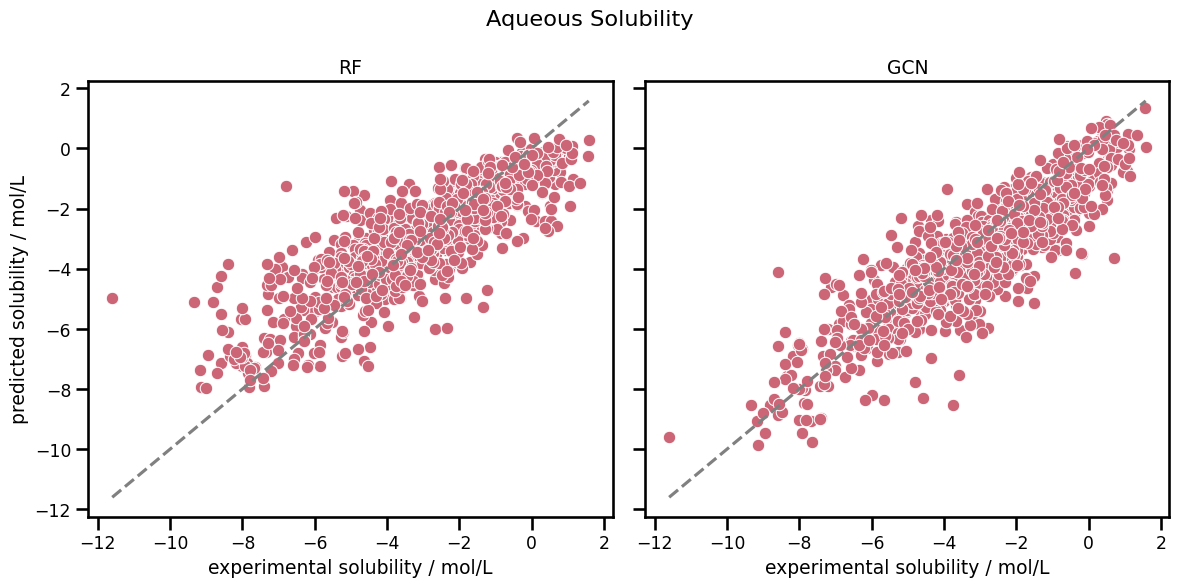

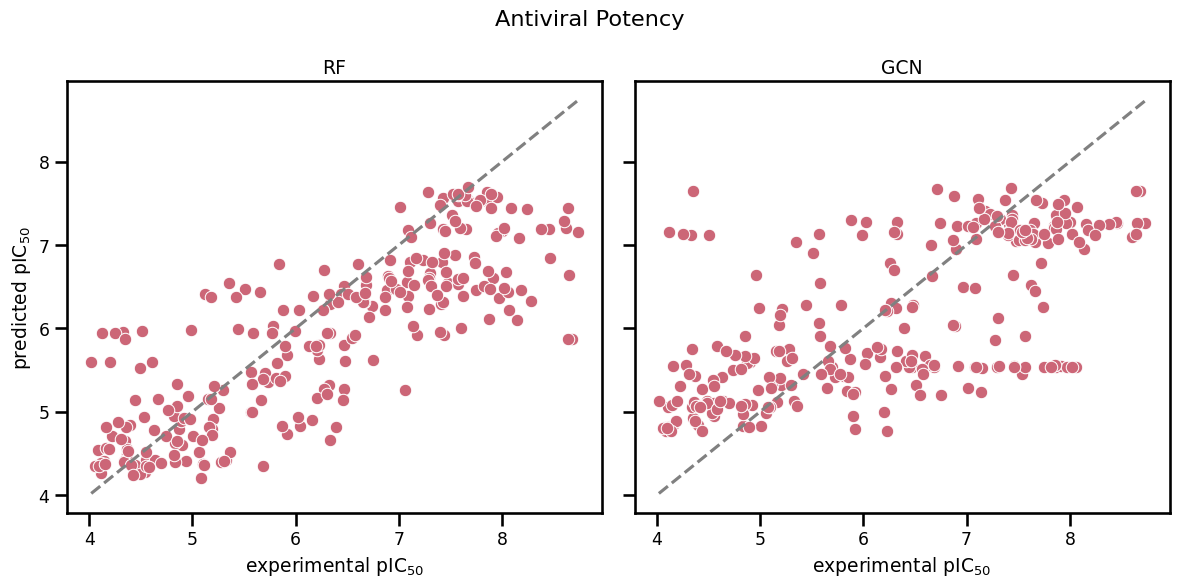

In [39]:
models=['RF', "GCN"]
datasets = ['esol_delaney', 'SARS']
labels = ['Aqueous Solubility', 'Antiviral Potency']
xy_labels = ['solubility / mol/L', 'pIC$_{50}$']

for dataset, label, xy_label in zip(datasets, labels, xy_labels):
    fig, axs = plt.subplots(1, len(models), figsize=(12, 6), sharey=True)
    for idx, model in enumerate(models):
        df = reg_df[(reg_df.dataset == dataset) & (reg_df.model == model)]
        y_test = np.concatenate(df.y_test)
        y_pred = np.concatenate(df.y_pred)
        sns.scatterplot(x=y_test, y=y_pred, ax=axs[idx])
        #axs[idx].scatter(y_test, y_pred)
        axs[idx].set_title(f"{model}")
        axs[idx].set_xlabel(f"experimental {xy_label}")
        axs[idx].set_ylabel(f"predicted {xy_label}")
        min_ = min(y_test.min(), y_pred.min())
        max_ = max(y_test.max(), y_pred.max())
        axs[idx].plot([min_, max_], [min_, max_], '--', color='gray')
    fig.suptitle(f"{label}")
    fig.tight_layout()
    fig.savefig(os.path.join(fig_folder, f"S_{dataset}_scatter.pdf"))
